# Supervised Denoising Autoencoder for CKD / AKI / Normal Biomarker Discovery

**Dataset:** `GSE183276_scCv3_with_metadata.h5ad`  
**Goal:** log-normalized single-cell RNA-seq data থেকে **CKD**, **AKI**, এবং **Normal/Ref** classify করা এবং important genes বের করা।

এই notebook cell-by-cell ভাবে সাজানো হয়েছে:

1. `.h5ad` dataset load
2. metadata check
3. CKD / AKI / Normal labels prepare
4. variance দিয়ে top **3000 HVG** select
5. train/test/validation split
6. supervised denoising autoencoder train
7. model evaluate
8. Gradient × Input দিয়ে important gene বের করা
9. CSV/Excel/figure save করা

## Cell 1 — Required packages

In [18]:
# Uncomment if needed
# !pip install scanpy anndata numpy pandas scipy scikit-learn matplotlib seaborn torch openpyxl

## Cell 2 — Import libraries and setup seed

কেন করা হচ্ছে:
- `scanpy` দিয়ে `.h5ad` read করা হবে।
- `torch` দিয়ে SDAE model train হবে।
- seed set করলে result তুলনামূলক reproducible হয়।

In [19]:
import os
import random
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sc.settings.verbosity = 2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU safe. GPU working হলে FORCE_CPU=False করো।
FORCE_CPU = True
if FORCE_CPU:
    DEVICE = "cpu"
else:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.5.1+cu121


## Cell 3 — Dataset path and output folders

`DATA_PATH` তোমার dataset location অনুযায়ী set করা আছে। Notebook অন্য folder থেকে run করলেও কয়েকটা fallback path check করবে।

In [20]:
DATA_PATH = "data/GSE183276_scCv3_with_metadata.h5ad"

possible_paths = [
    Path(DATA_PATH),
    Path("GSE183276_scCv3_with_metadata.h5ad"),
    Path("data/GSE183276_scCv3_with_metadata.h5ad"),
    Path.cwd() / DATA_PATH,
    Path.cwd().parent / DATA_PATH,
]

DATA_FILE = None
for p in possible_paths:
    if p.exists():
        DATA_FILE = p.resolve()
        break

if DATA_FILE is None:
    raise FileNotFoundError("Dataset not found. Please fix DATA_PATH.")

PROJECT_DIR = DATA_FILE.parent.parent if DATA_FILE.parent.name == "data" else DATA_FILE.parent
OUTPUT_DIR = PROJECT_DIR / "results_sdae_3000_variance_biomarkers"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for d in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_FILE)
print("Output directory:", OUTPUT_DIR)

Dataset: /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/data/GSE183276_scCv3_with_metadata.h5ad
Output directory: /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/results_sdae_3000_variance_biomarkers


## Cell 4 — Analysis parameters

কেন এগুলো দরকার:
- `N_TOP_HVG=3000`: variance দিয়ে top 3000 gene নেওয়া হবে।
- `MAX_CELLS_PER_CLASS`: class imbalance কমানোর জন্য balanced sampling।
- `NOISE_PROB`: denoising autoencoder training-এ random gene masking।
- `CLASS_LOSS_WEIGHT`: biomarker/classification goal গুরুত্বপূর্ণ, তাই classification loss একটু বেশি weight দেওয়া হয়েছে।

In [21]:
CONDITION_COL = "condition.l1"   # CKD, AKI, Ref
CELLTYPE_COL = "subclass.l1"     # PT, TAL, IMM, etc.

LABEL_RENAME = {
    "Ref": "Normal",
    "REF": "Normal",
    "reference": "Normal",
    "Healthy": "Normal",
    "Control": "Normal",
    "Normal": "Normal",
    "AKD": "AKI",   # typo safe
    "AKI": "AKI",
    "CKD": "CKD",
}
TARGET_CLASSES = ["Normal", "AKI", "CKD"]

N_TOP_HVG = 3000
TEST_SIZE = 0.20
VAL_SIZE_FROM_TRAIN = 0.15

BATCH_SIZE = 128
EPOCHS = 25
PATIENCE = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

NOISE_PROB = 0.20
LATENT_DIM = 32
HIDDEN_DIMS = (512, 128)
RECON_LOSS_WEIGHT = 1.0
CLASS_LOSS_WEIGHT = 1.5

MAX_CELLS_PER_CLASS = 4000
TOP_N_GENES_PER_CLASS = 200
IMPORTANCE_MAX_CELLS_PER_CLASS = 300

print("N_TOP_HVG:", N_TOP_HVG)
print("Target classes:", TARGET_CLASSES)
print("MAX_CELLS_PER_CLASS:", MAX_CELLS_PER_CLASS)

N_TOP_HVG: 3000
Target classes: ['Normal', 'AKI', 'CKD']
MAX_CELLS_PER_CLASS: 4000


## Cell 5 — Load `.h5ad` dataset

এখানে dataset memory তে load হবে এবং shape/metadata দেখা হবে।

In [22]:
adata = sc.read_h5ad(DATA_FILE)
print(adata)
print("Shape cells x genes:", adata.shape)
print("X type:", type(adata.X))
print("Available obs columns:")
print(list(adata.obs.columns))

display(adata.obs[[CONDITION_COL, CELLTYPE_COL]].head())

AnnData object with n_obs × n_vars = 109741 × 37080
    obs: 'sample', 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'gene_symbol'
    la

,condition.l1,subclass.l1
AKI3010018_AAACCCACAGGGATAC-1,AKI,PT
AKI3010018_AAACCCATCTGATGGT-1,AKI,EC
AKI3010018_AAACCCATCTGCTTTA-1,AKI,PT
AKI3010018_AAACGAATCTCCAATT-1,AKI,IMM
AKI3010018_AAACGAATCTTTCCAA-1,AKI,TAL


## Cell 6 — Condition and cell type count check

কেন দরকার:
- class distribution জানা দরকার।
- imbalance থাকলে balanced sampling দরকার হবে।

In [23]:
print("Condition counts:")
print(adata.obs[CONDITION_COL].astype(str).value_counts())

print("Cell type counts:")
print(adata.obs[CELLTYPE_COL].astype(str).value_counts())

Condition counts:
condition.l1
CKD    52314
AKI    35777
Ref    21650
Name: count, dtype: int64
Cell type counts:
subclass.l1
PT       25373
TAL      23894
IMM      17176
EC        8550
IC        8334
PC        7483
CNT       6459
DCT       5324
VSM/P     3011
DTL       1836
PEC       1005
ATL        431
FIB        372
POD        284
PapE       202
NEU          7
Name: count, dtype: int64


## Cell 7 — Prepare CKD / AKI / Normal labels


In [24]:
adata.obs["condition_clean"] = adata.obs[CONDITION_COL].astype(str).map(lambda x: LABEL_RENAME.get(x, x))
adata = adata[adata.obs["condition_clean"].isin(TARGET_CLASSES)].copy()

print("Clean condition counts:")
print(adata.obs["condition_clean"].value_counts())
print("Shape after condition filtering:", adata.shape)

Clean condition counts:
condition_clean
CKD       52314
AKI       35777
Normal    21650
Name: count, dtype: int64
Shape after condition filtering: (109741, 37080)


## Cell 8 — Balanced subsampling

কেন করা হচ্ছে:
- CKD cell বেশি হলে model CKD-dominated হয়ে যেতে পারে।
- প্রতিটি class থেকে maximum 4000 cell নেওয়া হচ্ছে।
- এতে CKD, AKI, Normal balanced ভাবে শেখে।

In [25]:
def balanced_subsample_adata(adata, label_col, max_per_class, seed=42):
    rng = np.random.default_rng(seed)
    selected = []
    for cls, idx in adata.obs.groupby(label_col).indices.items():
        idx = np.array(idx)
        if len(idx) > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)
        selected.extend(idx.tolist())
    selected = np.array(selected)
    rng.shuffle(selected)
    return adata[selected].copy()

adata_model = balanced_subsample_adata(adata, "condition_clean", MAX_CELLS_PER_CLASS, SEED)
print("Model data shape:", adata_model.shape)
print(adata_model.obs["condition_clean"].value_counts())

Model data shape: (12000, 37080)
condition_clean
AKI       4000
Normal    4000
CKD       4000
Name: count, dtype: int64


## Cell 9 — Select 3000 HVG by variance

কেন করা হচ্ছে:
- সব gene model এ দিলে noise/overfitting/memory issue হয়।
- বেশি variance থাকা gene biological difference ধরতে পারে।
- এখানে requested অনুযায়ী scanpy HVG না, simple variance ranking ব্যবহার করা হয়েছে।

In [26]:
def sparse_or_dense_variance(X):
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        var = mean_sq - mean ** 2
    else:
        var = np.var(np.asarray(X), axis=0)
    return np.asarray(var).ravel()

gene_var = sparse_or_dense_variance(adata_model.X)
top_idx = np.argsort(gene_var)[::-1][:N_TOP_HVG]
adata_hvg = adata_model[:, top_idx].copy()
adata_hvg.var["variance"] = gene_var[top_idx]
adata_hvg.var["variance_rank"] = np.arange(1, adata_hvg.n_vars + 1)

hvg_df = pd.DataFrame({
    "gene": adata_hvg.var_names,
    "variance": adata_hvg.var["variance"].values,
    "variance_rank": adata_hvg.var["variance_rank"].values,
})
hvg_df.to_csv(TABLE_DIR / "selected_3000_hvg_by_variance.csv", index=False)

print("HVG data shape:", adata_hvg.shape)
display(hvg_df.head(20))

HVG data shape: (12000, 3000)


,gene,variance,variance_rank
0,IGKC,93867.240325,1
1,IGLC3,49586.507726,2
2,MT-CO1,49518.242445,3
3,MALAT1,46529.824729,4
4,MT-ND3,45271.012378,5
5,MT-CO2,42881.031203,6
6,MT-CO3,20839.347750,7
7,IGLC2,14741.227034,8
8,MT-ATP6,10270.968052,9
9,MT-ND4,8973.121806,10


## Cell 10 — Make dense input matrix and encode labels

PyTorch model numeric dense matrix নেয়। তাই sparse হলে dense float32 করা হচ্ছে। Labels string থেকে integer encode করা হচ্ছে।

In [27]:
def to_dense_float32(X):
    if sp.issparse(X):
        X = X.toarray()
    return np.asarray(X, dtype=np.float32)

X = to_dense_float32(adata_hvg.X)
labels_str = adata_hvg.obs["condition_clean"].astype(str).values

y_encoder = LabelEncoder()
y = y_encoder.fit_transform(labels_str).astype(np.int64)
class_names = list(y_encoder.classes_)
gene_names = adata_hvg.var_names.to_numpy()

print("X shape:", X.shape)
print("Class names:", class_names)
print(pd.Series(labels_str).value_counts())

X shape: (12000, 3000)
Class names: ['AKI', 'CKD', 'Normal']
AKI       4000
Normal    4000
CKD       4000
Name: count, dtype: int64


## Cell 11 — Train / validation / test split

কেন করা হচ্ছে:
- Train: model শেখে।
- Validation: early stopping ও tuning।
- Test: final unseen evaluation।
- `stratify=y` দিলে প্রতিটি split এ class balance ঠিক থাকে।

In [28]:
all_idx = np.arange(X.shape[0])
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=VAL_SIZE_FROM_TRAIN, random_state=SEED, stratify=y[train_val_idx]
)

print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Train counts:")
print(pd.Series(labels_str[train_idx]).value_counts())
print("Val counts:")
print(pd.Series(labels_str[val_idx]).value_counts())
print("Test counts:")
print(pd.Series(labels_str[test_idx]).value_counts())

Train: 8160 Val: 1440 Test: 2400
Train counts:
Normal    2720
AKI       2720
CKD       2720
Name: count, dtype: int64
Val counts:
CKD       480
AKI       480
Normal    480
Name: count, dtype: int64
Test counts:
AKI       800
CKD       800
Normal    800
Name: count, dtype: int64


## Cell 12 — Dataset and DataLoader

Mini-batch training এর জন্য PyTorch Dataset/DataLoader বানানো হচ্ছে।

In [29]:
class ExpressionDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = torch.tensor(X[indices], dtype=torch.float32)
        self.y = torch.tensor(y[indices], dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ExpressionDataset(X, y, train_idx)
val_ds = ExpressionDataset(X, y, val_idx)
test_ds = ExpressionDataset(X, y, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Number of batches:", len(train_loader), len(val_loader), len(test_loader))

Number of batches: 64 12 19


## Cell 13 — Supervised Denoising Autoencoder architecture

Architecture:

```text
3000 genes
→ Encoder: 512 → 128
→ Latent: 32
→ Decoder: 128 → 512 → 3000 reconstructed genes
→ Classifier: CKD / AKI / Normal
```

Denoising অংশে random masking noise add করা হয়। Classifier head disease-specific signal শেখায়।

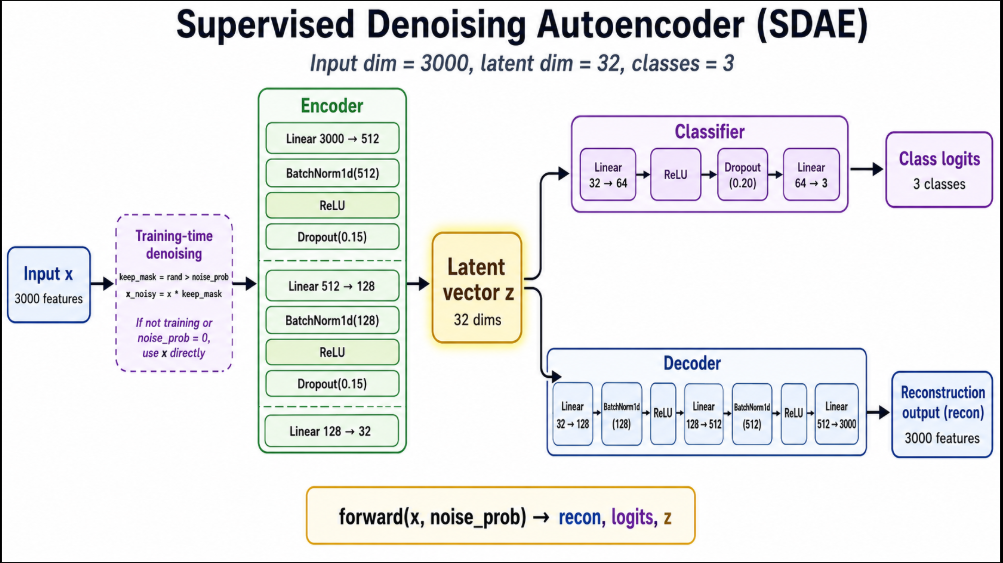

In [30]:
class SupervisedDenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim, n_classes):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.15)]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(0.20), nn.Linear(64, n_classes)
        )

    def forward(self, x, noise_prob=0.0):
        if self.training and noise_prob > 0:
            keep_mask = (torch.rand_like(x) > noise_prob).float()
            x_noisy = x * keep_mask
        else:
            x_noisy = x
        z = self.encoder(x_noisy)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return recon, logits, z

model = SupervisedDenoisingAutoencoder(
    input_dim=X.shape[1],
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    n_classes=len(class_names),
).to(DEVICE)

print(model)

SupervisedDenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=3000, bias=True)
  )
  (classifier): Sequential(
    (0

## Cell 14 — Loss, class weights, optimizer

Loss:

```text
Total loss = reconstruction loss + 1.5 × classification loss
```

কেন:
- reconstruction loss model কে expression pattern শিখায়।
- classification loss CKD/AKI/Normal আলাদা করতে শেখায়।
- class weight imbalance কমায়।

In [31]:
train_counts = np.bincount(y[train_idx], minlength=len(class_names))
class_weights_np = train_counts.sum() / (len(class_names) * train_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print("Train counts:", dict(zip(class_names, train_counts)))
print("Class weights:", dict(zip(class_names, np.round(class_weights_np, 3))))

Train counts: {'AKI': np.int64(2720), 'CKD': np.int64(2720), 'Normal': np.int64(2720)}
Class weights: {'AKI': np.float64(1.0), 'CKD': np.float64(1.0), 'Normal': np.float64(1.0)}


## Cell 15 — One epoch training/evaluation function

এই function train অথবা validation/test এক epoch চালায় এবং loss/accuracy/F1 return করে।

In [32]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = total_recon = total_cls = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            recon, logits, _ = model(xb, noise_prob=NOISE_PROB if is_train else 0.0)
            recon_loss = F.mse_loss(recon, xb)
            cls_loss = F.cross_entropy(logits, yb, weight=class_weights)
            loss = RECON_LOSS_WEIGHT * recon_loss + CLASS_LOSS_WEIGHT * cls_loss
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_recon += recon_loss.item() * xb.size(0)
        total_cls += cls_loss.item() * xb.size(0)
        pred = torch.argmax(logits, dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(pred.detach().cpu().numpy())

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "recon_loss": total_recon / n,
        "cls_loss": total_cls / n,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

## Cell 16 — Train model with early stopping

Validation macro-F1 improve না করলে early stopping হবে। Best model save করা হবে।

In [33]:
best_val_f1 = -np.inf
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer)
    val_metrics = run_epoch(model, val_loader, None)
    row = {"epoch": epoch}
    row.update({"train_" + k: v for k, v in train_metrics.items()})
    row.update({"val_" + k: v for k, v in val_metrics.items()})
    history.append(row)

    print(f"Epoch {epoch:03d} | train_loss={train_metrics['loss']:.4f}, train_F1={train_metrics['macro_f1']:.4f} | val_loss={val_metrics['loss']:.4f}, val_F1={val_metrics['macro_f1']:.4f}")

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), MODEL_DIR / "supervised_sdae_best_model.pt")
history_df = pd.DataFrame(history)
history_df.to_csv(TABLE_DIR / "training_history.csv", index=False)
display(history_df.tail())

Epoch 001 | train_loss=189.8938, train_F1=0.4890 | val_loss=160.0885, val_F1=0.5639
Epoch 002 | train_loss=159.0222, train_F1=0.6332 | val_loss=132.3193, val_F1=0.7326
Epoch 003 | train_loss=136.0145, train_F1=0.7195 | val_loss=117.8636, val_F1=0.7841
Epoch 004 | train_loss=118.8476, train_F1=0.7445 | val_loss=104.7496, val_F1=0.8103
Epoch 005 | train_loss=106.9579, train_F1=0.7663 | val_loss=86.4352, val_F1=0.7645
Epoch 006 | train_loss=98.6672, train_F1=0.7881 | val_loss=82.3035, val_F1=0.8356
Epoch 007 | train_loss=92.9756, train_F1=0.8075 | val_loss=75.8422, val_F1=0.8441
Epoch 008 | train_loss=89.4660, train_F1=0.8116 | val_loss=74.2401, val_F1=0.8527
Epoch 009 | train_loss=86.2510, train_F1=0.8227 | val_loss=71.2219, val_F1=0.8280
Epoch 010 | train_loss=84.0327, train_F1=0.8456 | val_loss=68.0587, val_F1=0.8453
Epoch 011 | train_loss=82.2475, train_F1=0.8419 | val_loss=66.8233, val_F1=0.8627
Epoch 012 | train_loss=80.0934, train_F1=0.8560 | val_loss=63.0420, val_F1=0.8483
Epoch 0

,epoch,train_loss,train_recon_loss,train_cls_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_recon_loss,val_cls_loss,val_accuracy,val_macro_f1,val_weighted_f1
20,21,67.763041,67.306130,0.304607,0.878922,0.878877,0.878877,46.332051,45.982642,0.232939,0.911111,0.910912,0.910912
21,22,65.932910,65.501943,0.287312,0.885172,0.885022,0.885022,42.429465,42.038387,0.260719,0.897222,0.898206,0.898206
22,23,66.373561,65.933578,0.293323,0.884804,0.884869,0.884869,41.541505,41.121540,0.279976,0.891667,0.892000,0.892000
23,24,64.094399,63.661537,0.288574,0.886642,0.886489,0.886489,41.411558,41.042197,0.246241,0.902778,0.903457,0.903457
24,25,64.633345,64.221203,0.274761,0.891176,0.891042,0.891042,37.693299,37.310934,0.254910,0.902778,0.902801,0.902801


## Cell 17 — Plot training curves

Loss এবং macro-F1 curve দেখে model learning behavior বোঝা যাবে।

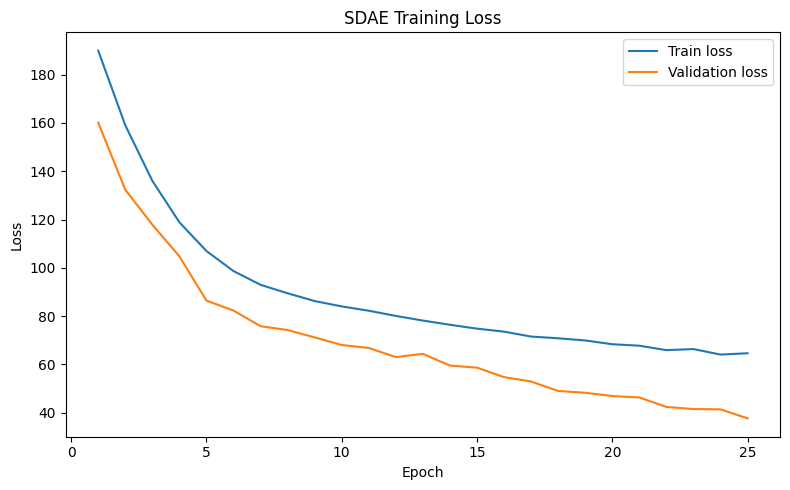

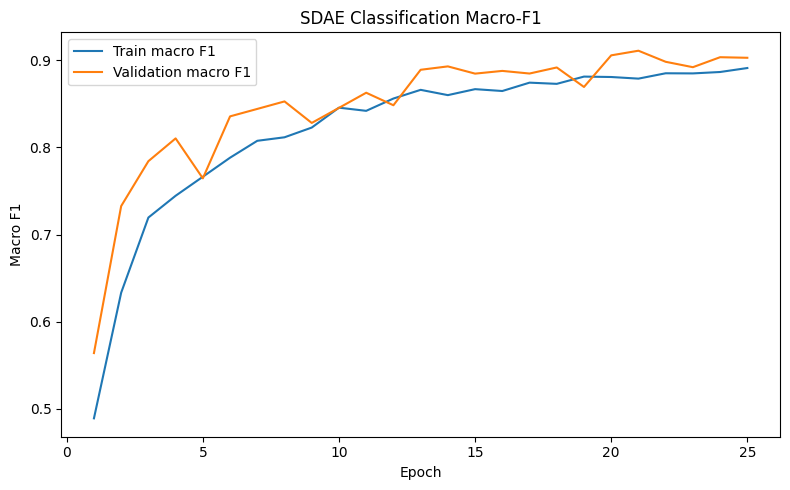

In [34]:
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SDAE Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("SDAE Classification Macro-F1")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_f1_curve.png", dpi=300)
plt.show()

## Cell 18 — Test evaluation

Final test set unseen ছিল। এই result thesis/model performance হিসেবে report করা যাবে।

In [35]:
def predict_loader(model, loader):
    model.eval()
    y_true, y_pred, probs_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            _, logits, _ = model(xb, noise_prob=0.0)
            probs = F.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1)
            y_true.extend(yb.numpy())
            y_pred.extend(pred.cpu().numpy())
            probs_all.append(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(probs_all)

y_test_true, y_test_pred, test_probs = predict_loader(model, test_loader)
acc = accuracy_score(y_test_true, y_test_pred)
macro_f1 = f1_score(y_test_true, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test_true, y_test_pred, average="weighted")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
report_text = classification_report(y_test_true, y_test_pred, target_names=class_names)
print(report_text)

with open(TABLE_DIR / "classification_report.txt", "w") as f:
    f.write(report_text)
metrics_df = pd.DataFrame([{"accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1, "n_test": len(y_test_true)}])
metrics_df.to_csv(TABLE_DIR / "test_metrics.csv", index=False)
display(metrics_df)

Accuracy: 0.89875
Macro F1: 0.8982441397910454
Weighted F1: 0.8982441397910456
              precision    recall  f1-score   support

         AKI       0.88      0.88      0.88       800
         CKD       0.87      0.84      0.86       800
      Normal       0.95      0.97      0.96       800

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



,accuracy,macro_f1,weighted_f1,n_test
0,0.89875,0.898244,0.898244,2400


## Cell 19 — Confusion matrix

কোন class ঠিক/ভুল predict হচ্ছে সেটা দেখা হবে।

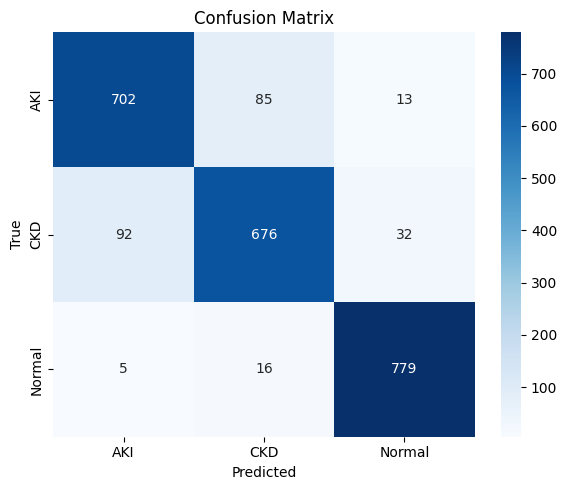

In [36]:
cm = confusion_matrix(y_test_true, y_test_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(TABLE_DIR / "confusion_matrix.csv")

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=300)
plt.show()

## Cell 20 — Extract latent representation

Latent হলো encoder-এর শেখা compressed feature। CKD/AKI/Normal আলাদা হচ্ছে কিনা PCA plot-এ দেখা যাবে।

In [37]:
def get_latent(model, X_array, batch_size=512):
    model.eval()
    zs = []
    with torch.no_grad():
        for start in range(0, X_array.shape[0], batch_size):
            xb = torch.tensor(X_array[start:start+batch_size], dtype=torch.float32).to(DEVICE)
            _, _, z = model(xb, noise_prob=0.0)
            zs.append(z.cpu().numpy())
    return np.vstack(zs)

Z = get_latent(model, X)
latent_df = pd.DataFrame(Z, columns=[f"latent_{i+1}" for i in range(Z.shape[1])])
latent_df["condition"] = labels_str
latent_df.to_csv(TABLE_DIR / "latent_representation.csv", index=False)
print("Latent shape:", Z.shape)
display(latent_df.head())

Latent shape: (12000, 32)


,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,...,latent_24,latent_25,latent_26,latent_27,latent_28,latent_29,latent_30,latent_31,latent_32,condition
0,1.541050,1.598409,-0.529967,1.639496,0.186625,2.008371,0.567771,-0.781965,0.930749,0.923686,...,1.451083,0.068750,2.107955,0.496331,-0.628192,0.568027,1.056322,0.449858,1.538607,AKI
1,-0.809112,-4.027951,-2.588769,6.423008,-4.379623,-3.466055,2.888737,0.188761,1.125717,0.048551,...,5.661168,-5.361804,1.770165,2.167884,8.364954,-5.261396,6.882008,7.467951,-2.561247,AKI
2,-0.380638,-0.349379,0.298107,-1.087895,1.258622,-0.996003,-0.242819,1.112814,-0.331236,-0.056811,...,-0.900096,-0.089188,-0.920673,-0.214068,-0.584856,-0.515441,-0.066049,0.382713,-0.244664,Normal
3,-1.563645,-1.015733,0.056740,0.663600,0.522756,-1.675505,1.388313,0.605905,-1.676898,-0.752130,...,2.076028,-1.290503,0.174698,1.610987,1.770829,-1.461731,2.786175,1.686982,-0.825882,AKI
4,1.316300,0.767445,-0.877567,0.001682,0.111026,0.689060,0.390453,-0.431322,-0.615157,0.451564,...,0.308295,0.207840,0.295561,-0.827007,-0.753249,0.399006,0.760867,-0.142709,0.097006,CKD


## Cell 21 — Latent PCA visualization

Latent feature PCA করে disease separation visualize করা হচ্ছে।

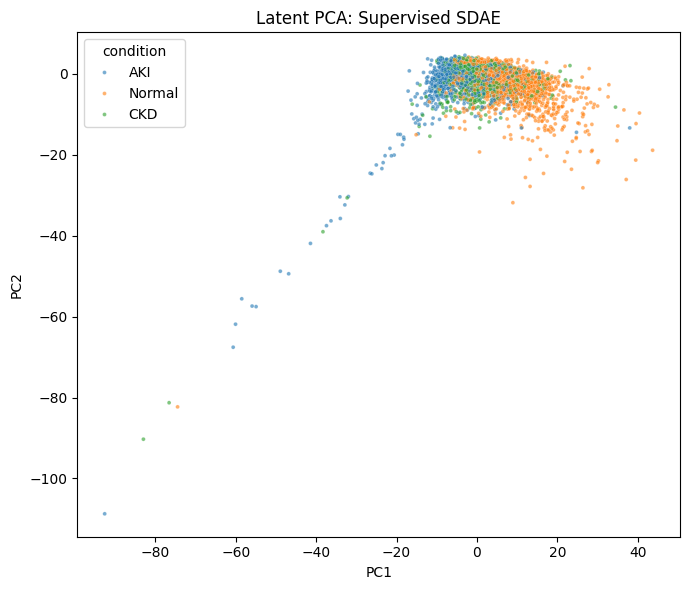

In [38]:
pca = PCA(n_components=2, random_state=SEED)
Z_pca = pca.fit_transform(Z)
plot_df = pd.DataFrame({"PC1": Z_pca[:,0], "PC2": Z_pca[:,1], "condition": labels_str})

plt.figure(figsize=(7,6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="condition", s=8, alpha=0.6)
plt.title("Latent PCA: Supervised SDAE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "latent_pca_condition.png", dpi=300)
plt.show()

## Cell 22 — Important genes by Gradient × Input

কেন করা হচ্ছে:
- কোন genes model prediction-এ বেশি contribute করছে সেটা বের করতে।
- প্রতিটি class-এর জন্য আলাদা importance score calculate করা হবে।

Formula idea:

```text
importance = abs(gradient × input expression)
```

এগুলো candidate biomarkers, final biomarkers না।

In [39]:
def gradient_x_input_importance(model, X_array, labels_array, class_id, max_cells=300, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.where(labels_array == class_id)[0]
    if len(idx) > max_cells:
        idx = rng.choice(idx, size=max_cells, replace=False)

    X_sel = torch.tensor(X_array[idx], dtype=torch.float32, requires_grad=True).to(DEVICE)
    model.eval()
    _, logits, _ = model(X_sel, noise_prob=0.0)
    score = logits[:, class_id].sum()
    model.zero_grad(set_to_none=True)
    score.backward()

    grads = X_sel.grad.detach()
    gxinput = torch.abs(grads * X_sel).detach().cpu().numpy()
    importance = gxinput.mean(axis=0)
    return importance, idx

all_tables = []
for class_id, class_name in enumerate(class_names):
    importance, used_idx = gradient_x_input_importance(model, X, y, class_id, IMPORTANCE_MAX_CELLS_PER_CLASS, SEED + class_id)
    df = pd.DataFrame({
        "gene": gene_names,
        "class": class_name,
        "importance": importance,
        "variance": adata_hvg.var["variance"].values,
        "variance_rank": adata_hvg.var["variance_rank"].values,
        "n_cells_used": len(used_idx),
    }).sort_values("importance", ascending=False)
    df["importance_rank"] = np.arange(1, len(df)+1)
    df.to_csv(TABLE_DIR / f"gene_importance_{class_name}.csv", index=False)
    all_tables.append(df)

importance_all = pd.concat(all_tables, ignore_index=True)
importance_all.to_csv(TABLE_DIR / "gene_importance_all_classes.csv", index=False)
display(importance_all.groupby("class").head(10))

,gene,class,importance,variance,variance_rank,n_cells_used,importance_rank
0,MT-ND4,AKI,0.310751,8973.121806,10,300,1
1,MT-ND3,AKI,0.299501,45271.012378,5,300,2
2,SPP1,AKI,0.291183,2306.025641,18,300,3
3,MT-CO1,AKI,0.253621,49518.242445,3,300,4
4,WFDC2,AKI,0.164791,1778.594379,20,300,5
5,MT-ND2,AKI,0.151421,4815.301882,14,300,6
6,MT-ATP6,AKI,0.151213,10270.968052,9,300,7
7,RPS4Y1,AKI,0.134943,4.333793,575,300,8
8,MALAT1,AKI,0.131526,46529.824729,4,300,9
9,MT-ND1,AKI,0.127199,3438.168690,17,300,10


## Cell 23 — Top class-specific biomarker candidates

প্রতিটি class থেকে top important genes নেওয়া হচ্ছে।

In [40]:
top_biomarkers = (
    importance_all.sort_values(["class", "importance"], ascending=[True, False])
    .groupby("class")
    .head(TOP_N_GENES_PER_CLASS)
    .reset_index(drop=True)
)

top_biomarkers.to_csv(TABLE_DIR / "top_biomarker_genes_per_class.csv", index=False)
top_biomarkers.to_excel(TABLE_DIR / "top_biomarker_genes_per_class.xlsx", index=False)
display(top_biomarkers.groupby("class").head(20))

,gene,class,importance,variance,variance_rank,n_cells_used,importance_rank
0,MT-ND4,AKI,0.310751,8973.121806,10,300,1
1,MT-ND3,AKI,0.299501,45271.012378,5,300,2
2,SPP1,AKI,0.291183,2306.025641,18,300,3
3,MT-CO1,AKI,0.253621,49518.242445,3,300,4
4,WFDC2,AKI,0.164791,1778.594379,20,300,5
5,MT-ND2,AKI,0.151421,4815.301882,14,300,6
6,MT-ATP6,AKI,0.151213,10270.968052,9,300,7
7,RPS4Y1,AKI,0.134943,4.333793,575,300,8
8,MALAT1,AKI,0.131526,46529.824729,4,300,9
9,MT-ND1,AKI,0.127199,3438.168690,17,300,10


## Cell 24 — Top 20 gene plots

Thesis figure এর জন্য প্রতিটি class-এর top 20 important gene plot করা হচ্ছে।

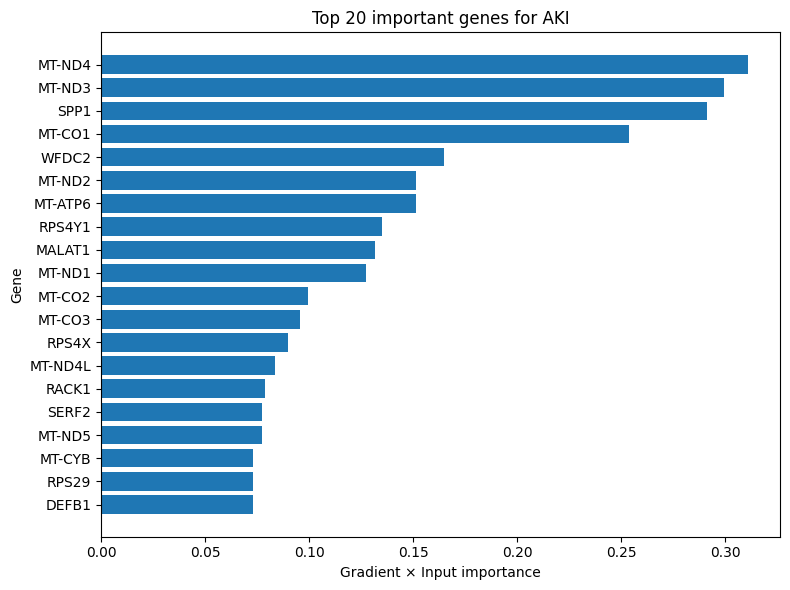

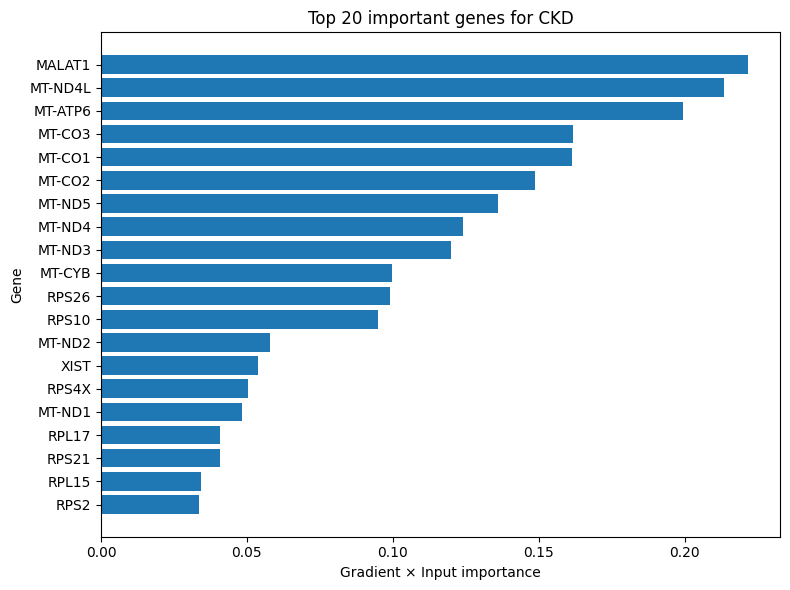

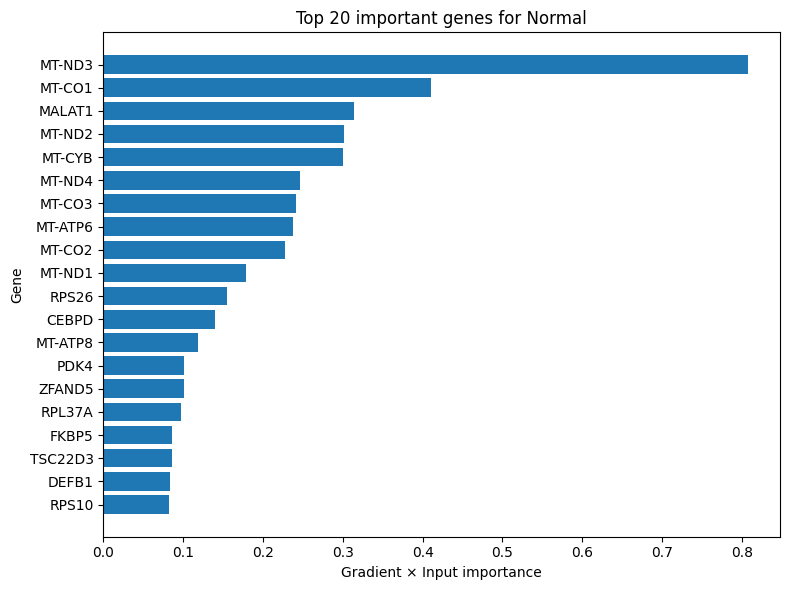

In [41]:
for class_name in class_names:
    df = top_biomarkers[top_biomarkers["class"] == class_name].head(20).copy()
    df = df.sort_values("importance", ascending=True)
    plt.figure(figsize=(8,6))
    plt.barh(df["gene"], df["importance"])
    plt.xlabel("Gradient × Input importance")
    plt.ylabel("Gene")
    plt.title(f"Top 20 important genes for {class_name}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"top20_genes_{class_name}.png", dpi=300)
    plt.show()

## Cell 25 — Mean expression summary of top genes

Importance score-এর সাথে class-wise mean expression দিলে biological interpretation সহজ হয়।

In [42]:
unique_genes = top_biomarkers["gene"].drop_duplicates().values
selected_idx = [np.where(gene_names == g)[0][0] for g in unique_genes]
rows = []
for g, gi in zip(unique_genes, selected_idx):
    row = {"gene": g}
    for cls in class_names:
        row[f"mean_expr_{cls}"] = float(X[labels_str == cls, gi].mean())
    rows.append(row)
expr_summary = pd.DataFrame(rows)
expr_summary.to_csv(TABLE_DIR / "top_biomarker_expression_summary.csv", index=False)
expr_summary.to_excel(TABLE_DIR / "top_biomarker_expression_summary.xlsx", index=False)
display(expr_summary.head(20))

,gene,mean_expr_AKI,mean_expr_CKD,mean_expr_Normal
0,MT-ND4,77.187576,88.466888,130.326447
1,MT-ND3,103.713264,143.760544,302.714783
2,SPP1,25.889168,9.095434,6.065105
3,MT-CO1,142.420303,162.052277,285.214844
4,WFDC2,19.903996,11.105254,4.239482
5,MT-ND2,30.725979,46.313694,89.664642
6,MT-ATP6,77.464470,82.419556,152.142075
7,RPS4Y1,1.343147,0.237282,0.733566
8,MALAT1,83.484505,103.965500,192.492630
9,MT-ND1,21.591578,33.826946,71.498894


## Cell 26 — Save summary README

এই cell final run summary save করবে।

In [43]:
summary = f"""# SDAE Biomarker Discovery Summary

Dataset: {DATA_FILE}
Original filtered shape: {adata.shape}
Balanced model shape: {adata_model.shape}
HVG data shape: {adata_hvg.shape}
Condition column: {CONDITION_COL}
Classes: {class_names}
N_TOP_HVG: {N_TOP_HVG}
Model: Supervised Denoising Autoencoder
Hidden dims: {HIDDEN_DIMS}
Latent dim: {LATENT_DIM}
Noise probability: {NOISE_PROB}
Test accuracy: {acc:.4f}
Test macro F1: {macro_f1:.4f}
Test weighted F1: {weighted_f1:.4f}

Important output files:
- {TABLE_DIR / 'selected_3000_hvg_by_variance.csv'}
- {TABLE_DIR / 'training_history.csv'}
- {TABLE_DIR / 'test_metrics.csv'}
- {TABLE_DIR / 'confusion_matrix.csv'}
- {TABLE_DIR / 'gene_importance_all_classes.csv'}
- {TABLE_DIR / 'top_biomarker_genes_per_class.xlsx'}
- {TABLE_DIR / 'top_biomarker_expression_summary.xlsx'}
- {MODEL_DIR / 'supervised_sdae_best_model.pt'}
"""

with open(OUTPUT_DIR / "README_summary.md", "w") as f:
    f.write(summary)
print(summary)

# SDAE Biomarker Discovery Summary

Dataset: /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/data/GSE183276_scCv3_with_metadata.h5ad
Original filtered shape: (109741, 37080)
Balanced model shape: (12000, 37080)
HVG data shape: (12000, 3000)
Condition column: condition.l1
Classes: ['AKI', 'CKD', 'Normal']
N_TOP_HVG: 3000
Model: Supervised Denoising Autoencoder
Hidden dims: (512, 128)
Latent dim: 32
Noise probability: 0.2
Test accuracy: 0.8988
Test macro F1: 0.8982
Test weighted F1: 0.8982

Important output files:
- /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/results_sdae_3000_variance_biomarkers/tables/selected_3000_hvg_by_variance.csv
- /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/results_sdae_3000_variance_biomarkers/tables/training_history.csv
- /home/nazmul/Research/SDAE_GSE183276_3000HVG_supervised_biomarker_ready/results_sdae_3000_variance_biomarkers/tables/test_metrics.csv
- /home/nazmul/Research/SDAE_

# Final thesis note

এই notebook থেকে পাওয়া genes হলো **candidate biomarkers**। Final biomarker বলার আগে DEG analysis, cell-type expression check, literature support এবং external validation করা ভালো।

Recommended thesis wording:

> A supervised denoising autoencoder was trained on 3000 variance-selected genes from log-normalized single-cell RNA-seq data. The model jointly optimized expression reconstruction and CKD/AKI/Normal classification. Class-specific gene importance was estimated using Gradient × Input attribution, and top-ranked genes were considered candidate biomarker genes.